$$
\providecommand{\bm}{\boldsymbol}
\providecommand{\R}{\mathbb{R}}
\providecommand{\xv}{\mathbf{x}}
\providecommand{\thetav}{\bm{\theta}}
\providecommand{\thetab}{\bm{\theta}}
$$

INSERT_setup_intro

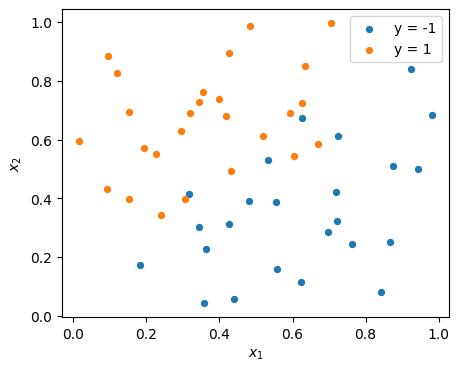

In [1]:
#| label: setup_data
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

X = np.random.uniform(size=(50, 2))
lin = X @ np.array([-1.0, 1.0]) + np.random.normal(0, 0.1, 50)
y = -((lin < 0).astype(int) * 2 - 1)

fig, ax = plt.subplots(figsize=(5, 4))
for label in (-1, 1):
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1], label=f"y = {label}", s=18)
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.legend()
plt.show()

INSERT_seeds_note

INSERT_problem_intro

INSERT_problem_a

**Solution.**

INSERT_solution_a_text

INSERT_problem_b

**Solution.**

INSERT_solution_b_text

INSERT_problem_c

In [2]:
#| label: solution_c_code
def f(theta):
    """SVM objective: ||theta||^2 + sum hinge(1 - y_i (X_i . theta))."""
    theta = np.asarray(theta, dtype=float)
    return float(theta @ theta + np.maximum(1 - y * (X @ theta), 0).sum())


def ft1(theta_1):
    return f(np.array([theta_1, 2.0]))


# phi = (sqrt(5) - 1) / 2 is the golden ratio reciprocal (~0.618).
# Picking the inner candidates at this fraction shrinks the bracket by exactly
# (1 - phi) ~= 0.382 each iteration AND lets us reuse one of the two previous
# evaluation points - so only ONE new function call per iteration is needed.
phi = (np.sqrt(5) - 1) / 2


def gr(f, lx=-3.0, rx=3.0, abs_error=0.01):
    xbest_old = np.inf
    iters = 0
    dist = rx - lx
    cx = [lx + (1 - phi) * dist, rx - (1 - phi) * dist]
    while True:
        iters += 1
        fcx1 = f(cx[0])
        fcx2 = f(cx[1])
        # Keep the side containing the better candidate; reflect the discarded
        # side's outer bound through golden ratio so we reuse one prior eval.
        if fcx1 < fcx2:
            fbest, xbest = fcx1, cx[0]
            rx = cx[1]
            cx[1] = cx[1] - (cx[0] - lx)
        else:
            fbest, xbest = fcx2, cx[1]
            lx = cx[0]
            cx[0] = cx[0] + (rx - cx[1])
        cx = sorted(cx)
        if abs(xbest_old - xbest) < abs_error:
            return {"xbest": xbest, "fbest": fbest, "iters": iters}
        xbest_old = xbest


res_gr = gr(ft1)
print(f"golden-section: theta_1* = {res_gr['xbest']:.4f}, "
      f"f = {res_gr['fbest']:.4f}, iters = {res_gr['iters']}")

golden-section: theta_1* = -2.1246, f = 31.8233, iters = 4


INSERT_problem_d

**Solution.**

INSERT_solution_d_text

INSERT_problem_e

INSERT_brent_intro_note

In [3]:
#| label: solution_e_code
def gr_step(f, lx, rx):
    """One golden-section step. Uses the parameter f (not a hardcoded ft1)."""
    dist = rx - lx
    cxs = [lx + (1 - phi) * dist, rx - (1 - phi) * dist]
    fcx = [f(c) for c in cxs]
    if fcx[0] < fcx[1]:
        fbest, cx, rx = fcx[0], cxs[0], cxs[1]
    else:
        fbest, cx, lx = fcx[1], cxs[1], cxs[0]
    return lx, rx, cx, fbest


def brent(f, lx=-3.0, rx=3.0, abs_error=0.01):
    xbest_old = np.inf
    iters = parabola_steps = golden_steps = 0
    first_step = True
    cx = None
    fbest = None
    while True:
        iters += 1

        if first_step or cx <= lx or cx >= rx:
            # First iter or previous candidate outside bracket: golden step
            lx, rx, cx, fbest = gr_step(f, lx, rx)
            xbest = cx
            golden_steps += 1
            first_step = False
        else:
            # Quadratic interpolation: parabola through (lx, rx, cx) -> vertex
            xs = [lx, rx, cx]
            fxs = [f(x) for x in xs]
            A = np.array([[x ** 2, x, 1.0] for x in xs])
            params = np.linalg.solve(A, fxs)
            cx_new = -params[1] / (2 * params[0])
            if lx < cx_new < rx:
                cxs = sorted([cx, cx_new])
                fcx = [f(c) for c in cxs]
                if fcx[0] < fcx[1]:
                    fbest, cx, rx = fcx[0], cxs[0], cxs[1]
                else:
                    fbest, cx, lx = fcx[1], cxs[1], cxs[0]
                xbest = cx
                parabola_steps += 1
            else:
                # Parabola vertex outside bracket: golden fallback
                lx, rx, cx, fbest = gr_step(f, lx, rx)
                xbest = cx
                golden_steps += 1

        if abs(xbest - xbest_old) < abs_error:
            return {
                "xbest": xbest, "fbest": fbest, "iters": iters,
                "parabola_steps": parabola_steps, "golden_steps": golden_steps,
            }
        xbest_old = xbest


res_br = brent(ft1)
print(f"Brent:          theta_1* = {res_br['xbest']:.4f}, "
      f"f = {res_br['fbest']:.4f}, iters = {res_br['iters']} "
      f"(parabola={res_br['parabola_steps']}, golden={res_br['golden_steps']})")
print(f"golden-section: iters = {res_gr['iters']}  (from c)")

Brent:          theta_1* = -1.8411, f = 31.7194, iters = 3 (parabola=2, golden=1)
golden-section: iters = 4  (from c)


INSERT_brent_cost_note

INSERT_problem_f

INSERT_cd_link_note

In [4]:
#| label: solution_f_code
t1, t2 = 0.0, 0.0
trace = [(t1, t2)]

for i in range(10):
    if i % 2 == 0:
        res = gr(lambda t: f(np.array([t, t2])))
        t1 = res["xbest"]
    else:
        res = gr(lambda t: f(np.array([t1, t])))
        t2 = res["xbest"]
    trace.append((t1, t2))
    print(f"iter {i:2d}: theta = ({t1:+.4f}, {t2:+.4f}), "
          f"f = {f(np.array([t1, t2])):.4f}")

iter  0: theta = (-0.7082, +0.0000), f = 46.6452
iter  1: theta = (-0.7082, +1.5836), f = 36.2619
iter  2: theta = (-1.5836, +1.5836), f = 33.1057
iter  3: theta = (-1.5836, +2.1246), f = 32.3456
iter  4: theta = (-2.1246, +2.1246), f = 31.5999
iter  5: theta = (-2.1246, +2.1246), f = 31.5999
iter  6: theta = (-2.1246, +2.1246), f = 31.5999
iter  7: theta = (-2.1246, +2.1246), f = 31.5999
iter  8: theta = (-2.1246, +2.1246), f = 31.5999
iter  9: theta = (-2.1246, +2.1246), f = 31.5999


INSERT_problem_g

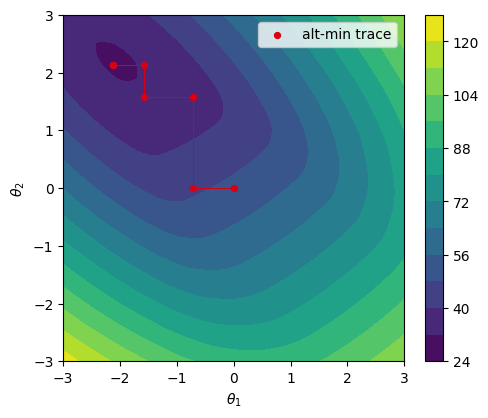

In [5]:
#| label: solution_g_code
grid = np.arange(-3, 3 + 0.1, 0.1)
T1, T2 = np.meshgrid(grid, grid)
Z = np.array([[f(np.array([t1_, t2_])) for t1_ in grid] for t2_ in grid])

trace_arr = np.array(trace)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
cs = ax.contourf(T1, T2, Z, levels=14)
ax.plot(trace_arr[:, 0], trace_arr[:, 1], color="#D90012", linewidth=0.7)
ax.scatter(trace_arr[:, 0], trace_arr[:, 1], color="#D90012", s=18,
           label="alt-min trace")
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.legend()
fig.colorbar(cs)
plt.show()

INSERT_solution_g_text